# ANÁLISIS DINÁMICO BÁSICO DE CARTERAS

# Análisis de Carteras: Efecto de la Evolución de Precios y el Rebalanceo

Hasta el momento, nuestros estudios de las diferentes estrategias de carteras se han centrado en la selección de activos y la asignación de pesos sin considerar la evolución temporal de los precios de los activos ni la posibilidad de realizar ajustes periódicos o rebalanceo. Estos factores pueden tener un impacto significativo en el rendimiento y el riesgo de las carteras.

En este notebook, exploraremos un análisis básico que incorpora tanto la dinámica de los precios de los activos como la estrategia de rebalanceo. Examinaremos cómo estos elementos afectan la evolución del valor de diferentes carteras a lo largo del tiempo, permitiéndonos obtener una comprensión más profunda de cada estrategia de inversión en un contexto más dinámico y realista. Además, consideraremos el impacto de las comisiones o gastos asociados al rebalanceo, lo que nos permite evaluar de manera más completa el rendimiento neto de las carteras.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import cvxpy as cp
from tqdm.auto import tqdm
import statsmodels.api as sm
import warnings
from scipy.linalg import sqrtm

plt.style.use("ggplot")
warnings.simplefilter(action="ignore", category=FutureWarning)


c:\WorkingFolderPersonal\microcredencial-carteras-python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Descarga de datos de índice

In [2]:
start_date = "1995-01-01"
precios_indice = yf.download("SPY", start=start_date, auto_adjust=False)[["Adj Close"]]  # Precios ajustados al cierre

[*********************100%***********************]  1 of 1 completed


Descarga de los componentes del índice

In [4]:
filepath = "https://raw.githubusercontent.com/alfonso-santos/microcredencial-carteras-python-2023/main/Tema_5_APT/data/sp500_tickers.csv"
tickers_sp500 = list(pd.read_csv(filepath))

precios = yf.download(tickers_sp500, start=start_date, auto_adjust=False)["Adj Close"]

precios_activos_sp500 = precios.copy()
precios_activos_sp500.dropna(axis=1, inplace=True)

$BF.B: possibly delisted; no price data found  (1d 1995-01-01 -> 2026-04-16)
[*                      3%                       ]  16 of 503 completedHTTP Error 404: Not Found{"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: JNPR"}}}
[**                     5%                       ]  24 of 503 completed$JNPR: possibly delisted; no timezone found
[****                   8%                       ]  39 of 503 completedHTTP Error 404: Not Found{"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HES"}}}
[****                   9%                       ]  44 of 503 completed$HES: possibly delisted; no timezone found
[*****                 11%                       ]  54 of 503 completed$CTLT: possibly delisted; no timezone found
[********              17%                       ]  84 of 503 completed$K: possibly delisted; no timezone found
[*********             18%                       ]  93

In [6]:
precios_activos_sp500.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7873 entries, 1995-01-03 to 2026-04-15
Columns: 291 entries, AAPL to ZION
dtypes: float64(291)
memory usage: 17.5 MB


Elegimos un universo de activos formados por ``num_act_max`` activos elegidos aleatoriamente para generar las carteras

In [34]:
num_act, num_columnas = precios_activos_sp500.shape
num_act_max = 20

if num_act_max > num_columnas:
    raise ValueError(
        f"num_act_max ({num_act_max}) no puede ser mayor que el número de columnas disponibles ({num_columnas})."
    )

# Generar índices aleatorios para seleccionar 'num_act_max' activos sin repetición
rng = np.random.default_rng(seed=42)
indices_aleatorios = rng.choice(num_columnas, size=num_act_max, replace=False)

# Seleccionar las columnas del array original usando los índices aleatorios
precios_activos_select = precios_activos_sp500.iloc[:, indices_aleatorios]


Nuestra estrategia de rebalanceo consistirá en ajustar la composición de la cartera cada ``periodo_rebalanceo`` días, manteniendo los pesos asignados a cada activo durante este período. Para calcular los pesos de los activos utilizaremos ``look_back`` días de datos históricos.

In [8]:
periodo_rebalanceo = 21 * 3  # Aproximadamente 3 meses de trading
look_back = 252 * 5  # Aproximadamente 5 años de trading

Funciones que calculan los pesos de las distintas carteras

In [18]:
def cartera_min_vol(ret):
    """Función que calcula la cartera de mínima varianza para un DataFrame de rendimientos
    ret: DataFrame de rendimientos
    Retorna pesos_ajustados: Array con los pesos de la cartera de mínima varianza"""

    if isinstance(ret, pd.DataFrame):  # Verifico que el argumento sea un DataFrame
        num_act = ret.shape[1]
        matriz_cov = ret.cov().to_numpy()

        # Variables de decisión
        pesos = cp.Variable(num_act)

        # Restricciones
        constraints = [
            pesos >= 0,
            cp.sum(pesos) == 1,
        ]

        riesgo = cp.quad_form(pesos, matriz_cov)  # Riesgo de la cartera
        objective = cp.Minimize(riesgo)  # Minimizar la varianza

        # Problema y resuelvo
        prob = cp.Problem(objective, constraints)
        resultado = prob.solve()

        pesos_ajustados = np.array(
            [np.round(x, 3) if x > 10**-4 else 0 for x in pesos.value]
        )  # Pongo a cero los pesos menores a 10^-4 y redondeo a 3 decimales

        return pesos_ajustados

    else:
        raise ValueError(
            "La función cartera_min_vol solo acepta un DataFrame como argumento"
        )  # Si el argumento no es un DataFrame, lanzo un error

In [19]:
def cartera_max_sharpe(ret, ret_rf):
    """Función que calcula la cartera de máximo índice de Sharpe para un DataFrame de rendimientos
    ret: DataFrame de rendimientos
    ret_rf: Rendimiento del activo libre de riesgo
    Retorna pesos_ajustados: Array con los pesos de la cartera de máximo índice de Sharpe"""

    if isinstance(ret, pd.DataFrame):
        num_act = ret.shape[1]
        matriz_cov = ret.cov().to_numpy()
        retornos_esperados = ret.mean()

        # Variable de decisión (pesos del portafolio)
        x = cp.Variable(num_act)
        # Riesgo (desviación estándar) del portafolio
        riesgo = cp.quad_form(x, matriz_cov)

        # Cálculo de pi como retornos esperados menos la rantabilidad del activo libre de riesgo
        pi = np.array(retornos_esperados - ret_rf)

        # Restricciones
        constraints = [
            pi @ x == 1,  # para que el numerador sea 1
            x >= 0,
        ]  # sin posiciones cortas

        objective = cp.Minimize(riesgo)  # Minimizo el riesgo

        # Problema de optimización
        problema = cp.Problem(objective, constraints)

        # Resolver el problema
        resultado = problema.solve()

        # Normalizo los pesos
        pesos = x.value
        pesos /= pesos.sum()

        pesos_ajustados = np.array([np.round(x, 3) if x > 10**-4 else 0 for x in pesos])

        return pesos_ajustados

    else:
        raise ValueError("La función cartera_max_sharpe solo acepta un DataFrame como argumento")

In [20]:
def cartera_risk_parity(ret):
    """
    Función que calcula la cartera de riesgo paridad para un DataFrame de rendimientos
    ret: DataFrame de rendimientos
    Retorna pesos_ajustados: Array con los pesos de la cartera de riesgo paridad"""

    if isinstance(ret, pd.DataFrame):
        num_act = ret.shape[1]
        matriz_cov = ret.cov().to_numpy()
        retornos_esperados = ret.mean().to_numpy()

        b = 1 / num_act

        x = cp.Variable(num_act)
        gamma = cp.Variable(num_act, nonneg=True)
        psi = cp.Variable(nonneg=True)

        z = matriz_cov @ x

        obj = cp.pnorm(b**0.5 * psi - gamma, p=2)
        ret = retornos_esperados.T @ x

        constraints = [cp.sum(x) == 1, x >= 0, cp.SOC(psi, sqrtm(matriz_cov) @ x)]

        for i in range(num_act):
            constraints += [cp.SOC(x[i] + z[i], cp.vstack([2 * gamma[i], x[i] - z[i]]))]

        objective = cp.Minimize(obj * 1000)
        prob = cp.Problem(objective, constraints)
        prob.solve()

        pesos_ajustados = np.array([np.round(xi, 3) if xi > 10**-4 else 0 for xi in x.value])

        return pesos_ajustados

    else:
        raise ValueError("La función cartera_risk_parity solo acepta un DataFrame como argumento")

In [133]:
pesos_min_vol = {}
pesos_max_sharpe = {}
pesos_risk_parity = {}

for i in range(look_back, len(precios_activos_select) - periodo_rebalanceo, periodo_rebalanceo):
    # print(f"Rebalanceando en la apertura del día {i}...")
    # Seleccionamos los precios disponibles para el rebalanceo (hasta los de cierre del día anterior al rebalanceo).
    precios_rebalanceo = precios_activos_select.iloc[i - look_back : i]
    # Calculamos los rendimientos logarítmicos para el período de look_back.
    ret_rebalanceo = np.log(precios_rebalanceo).diff().dropna()
    # Obtenemos la fecha en la que hacemos el rebalanceo y, por tanto, desde la que son válidos los pesos calculados.
    fecha = precios_activos_select.index[i]
    # Calculamos los pesos de cada cartera y los guardamos en un diccionario con la fecha como clave.
    pesos_min_vol[fecha] = cartera_min_vol(ret_rebalanceo)
    pesos_max_sharpe[fecha] = cartera_max_sharpe(ret_rebalanceo, ret_rf=0.01 / 252)
    pesos_risk_parity[fecha] = cartera_risk_parity(ret_rebalanceo)

# Convertimos los diccionarios de pesos en DataFrames para facilitar su uso posterior.
pesos_min_vol_df = pd.DataFrame(pesos_min_vol).T
pesos_min_vol_df.columns = precios_activos_select.columns
pesos_max_sharpe_df = pd.DataFrame(pesos_max_sharpe).T
pesos_max_sharpe_df.columns = precios_activos_select.columns
pesos_risk_parity_df = pd.DataFrame(pesos_risk_parity).T
pesos_risk_parity_df.columns = precios_activos_select.columns

In [134]:
pesos_min_vol_df


Ticker,PNW,PFE,CMCSA,WEC,SWKS,QCOM,BIO,AVB,MSI,KMB,HD,ATO,INCY,SPG,AXP,PHM,ROP,HON,ODFL,KO
1999-12-29,0.165,0.020,0.009,0.155,0.008,0.000,0.061,0.216,0.008,0.041,0.000,0.101,0.001,0.133,0.000,0.0,0.029,0.005,0.013,0.035
2000-03-29,0.139,0.020,0.002,0.150,0.010,0.000,0.074,0.243,0.014,0.022,0.000,0.097,0.003,0.149,0.000,0.0,0.024,0.005,0.014,0.036
2000-06-28,0.125,0.020,0.002,0.138,0.010,0.000,0.076,0.269,0.012,0.020,0.000,0.093,0.001,0.151,0.000,0.0,0.028,0.000,0.014,0.041
2000-09-27,0.118,0.026,0.008,0.134,0.012,0.000,0.095,0.292,0.011,0.021,0.000,0.079,0.000,0.123,0.000,0.0,0.021,0.007,0.015,0.037
2000-12-27,0.124,0.026,0.010,0.117,0.009,0.000,0.094,0.303,0.010,0.023,0.000,0.078,0.000,0.125,0.000,0.0,0.023,0.005,0.015,0.038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-14,0.002,0.125,0.061,0.005,0.000,0.003,0.032,0.000,0.018,0.298,0.000,0.017,0.127,0.000,0.000,0.0,0.043,0.006,0.025,0.237
2025-01-15,0.005,0.121,0.053,0.005,0.000,0.003,0.034,0.000,0.025,0.313,0.000,0.005,0.121,0.000,0.000,0.0,0.044,0.006,0.022,0.241
2025-04-16,0.014,0.093,0.039,0.072,0.000,0.011,0.014,0.000,0.041,0.243,0.044,0.037,0.090,0.000,0.000,0.0,0.089,0.000,0.000,0.212
2025-07-18,0.016,0.084,0.035,0.041,0.000,0.014,0.007,0.000,0.060,0.211,0.051,0.077,0.084,0.000,0.003,0.0,0.052,0.018,0.000,0.245


Calculamos los retornos de cada una de las carteras a partir de los pesos y los retornos de los activos

In [135]:
px = precios_activos_select.iloc[precios_activos_select.index.get_loc(pesos_min_vol_df.index[0]) - 1 :, :]
retornos_activos_select = np.log(px).diff().dropna()
retornos_indice = np.log(precios_indice.loc[px.index]).diff().dropna()

In [136]:
pesos_min_vol_daily_df = pesos_min_vol_df.reindex(index=retornos_activos_select.index, method="ffill")
pesos_max_sharpe_daily_df = pesos_max_sharpe_df.reindex(index=retornos_activos_select.index, method="ffill")
pesos_risk_parity_daily_df = pesos_risk_parity_df.reindex(index=retornos_activos_select.index, method="ffill")


In [137]:
pesos_min_vol_daily_df.shape, retornos_activos_select.shape

((6613, 20), (6613, 20))

In [138]:
retornos_min_vol = pd.DataFrame(
    np.matrix(retornos_activos_select.values @ pesos_min_vol_daily_df.values.T).diagonal().T,
    index=retornos_activos_select.index,
    columns=["min_vol"],
)
retornos_max_sharpe = pd.DataFrame(
    np.matrix(retornos_activos_select.values @ pesos_max_sharpe_daily_df.values.T).diagonal().T,
    index=retornos_activos_select.index,
    columns=["max_sharpe"],
)
retornos_risk_parity = pd.DataFrame(
    np.matrix(retornos_activos_select.values @ pesos_risk_parity_daily_df.values.T).diagonal().T,
    index=retornos_activos_select.index,
    columns=["risk_parity"],
)

Graficamos la evolución de cada una de las carteras y del índice para comparar su desempeño a lo largo del tiempo, puponiendo que invertimos 1 dólar al inicio del período.

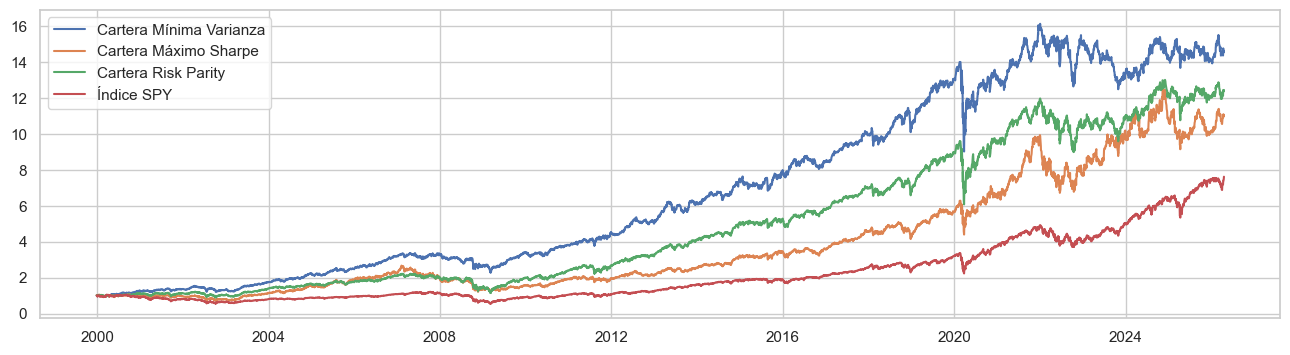

In [198]:
plt.figure(figsize=(16, 4))
plt.plot(np.exp(retornos_min_vol.cumsum()), label="Cartera Mínima Varianza")
plt.plot(np.exp(retornos_max_sharpe.cumsum()), label="Cartera Máximo Sharpe")
plt.plot(np.exp(retornos_risk_parity.cumsum()), label="Cartera Risk Parity")
plt.plot(np.exp(retornos_indice.cumsum()), label="Índice SPY")
plt.legend()
plt.show()

Veamos cómo se han comportado las carteras en cuanto a volatilidad

In [140]:
(
    retornos_min_vol.std() * np.sqrt(252),
    retornos_max_sharpe.std() * np.sqrt(252),
    retornos_risk_parity.std() * np.sqrt(252),
)


(min_vol    0.148509
 dtype: float64,
 max_sharpe    0.200886
 dtype: float64,
 risk_parity    0.177681
 dtype: float64)

In [141]:
print(f"La volatilidad de la cartera de mínima volatilidad es {np.std(retornos_min_vol.values) * np.sqrt(252):.2f}")
print(f"La volatilidad de la cartera de máximo sharpe es {np.std(retornos_max_sharpe.values) * np.sqrt(252):.2f}")
print(f"La volatilidad de la cartera de risk parity es {np.std(retornos_risk_parity.values) * np.sqrt(252):.2f}")

La volatilidad de la cartera de mínima volatilidad es 0.15
La volatilidad de la cartera de máximo sharpe es 0.20
La volatilidad de la cartera de risk parity es 0.18


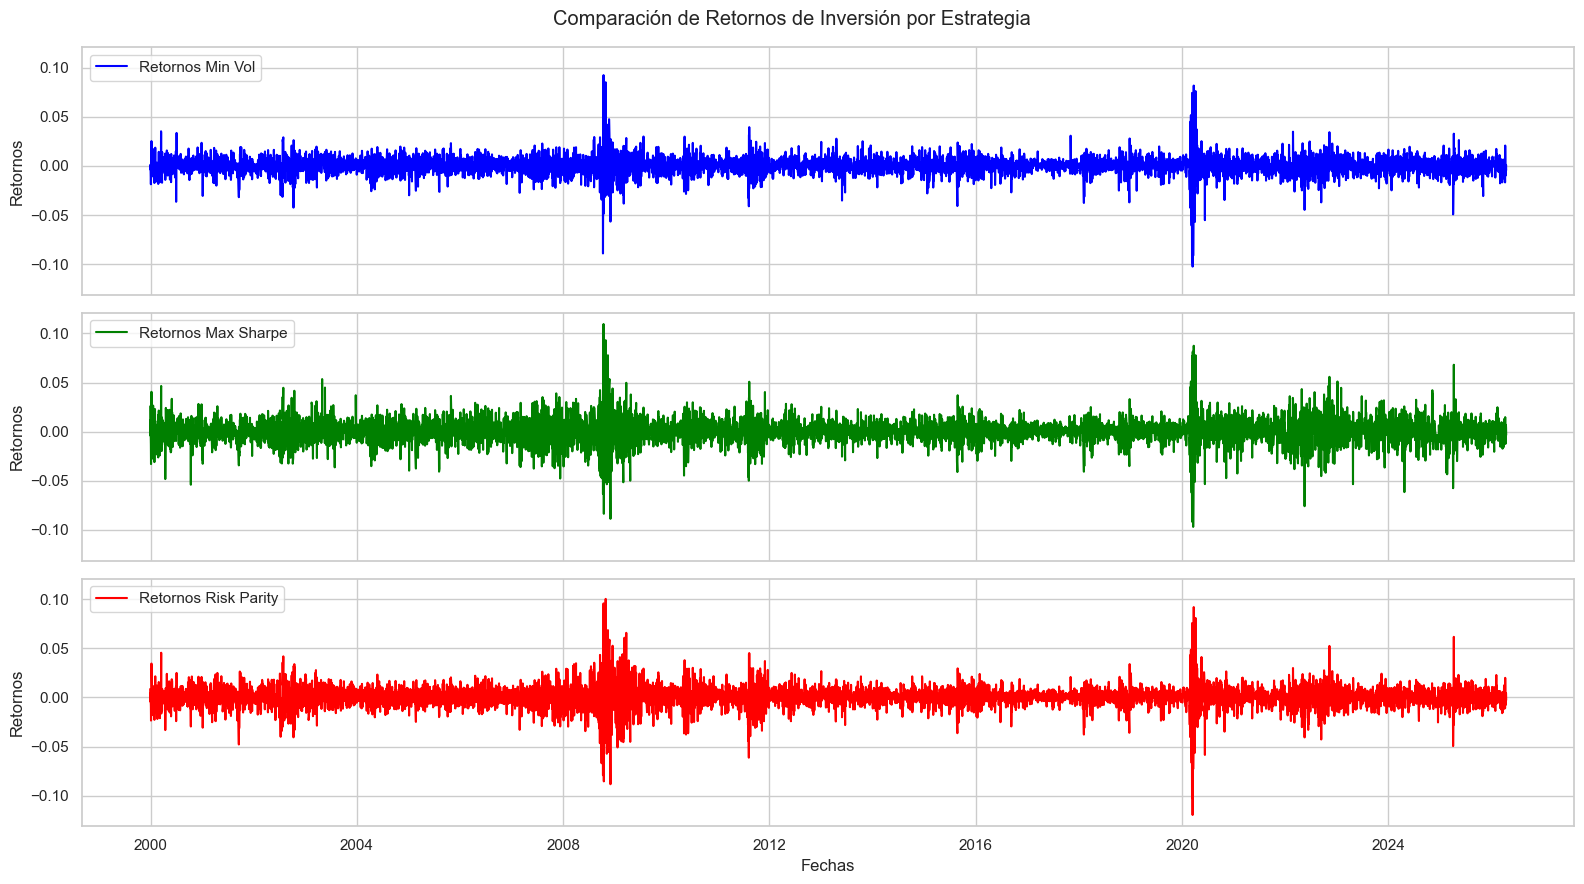

In [142]:
# Crear una figura y subgráficas
fig, axs = plt.subplots(
    3, 1, figsize=(16, 9), sharex=True, sharey=True
)  # 3 subgráficas, una para cada estrategia, compartiendo el eje x

# Dibujar cada serie de retornos en su propia subgráfica
axs[0].plot(retornos_min_vol, label="Retornos Min Vol", color="blue")
axs[1].plot(retornos_max_sharpe, label="Retornos Max Sharpe", color="green")
axs[2].plot(retornos_risk_parity, label="Retornos Risk Parity", color="red")

# Añadir título general y etiquetas
fig.suptitle("Comparación de Retornos de Inversión por Estrategia")
for ax in axs:
    ax.set_ylabel("Retornos")
    ax.legend(loc="upper left")  # Colocar leyenda en la parte superior izquierda

# Etiqueta para el eje x solo en la subgráfica inferior
axs[2].set_xlabel("Fechas")

# Ajustar automáticamente el layout
fig.tight_layout()  # Ajusta la subgráfica para dejar espacio para el título general

# Mostrar la gráfica
plt.show()


In [143]:
retornos_todas = pd.concat([retornos_min_vol, retornos_max_sharpe, retornos_risk_parity], axis=1)

In [144]:
retornos_todas.skew(), retornos_todas.kurtosis()

(min_vol       -0.425495
 max_sharpe    -0.153888
 risk_parity   -0.371088
 dtype: float64,
 min_vol        14.191608
 max_sharpe      6.257510
 risk_parity    11.440855
 dtype: float64)

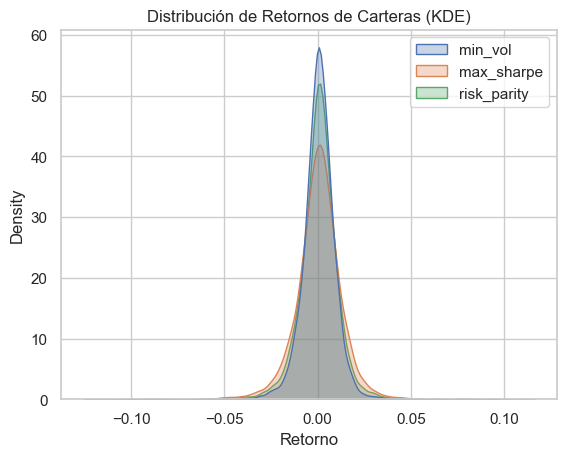

In [145]:
import seaborn as sns

sns.kdeplot(data=retornos_todas, fill=True, common_norm=False, alpha=0.3)
plt.xlabel("Retorno")
plt.title("Distribución de Retornos de Carteras (KDE)")
plt.show()

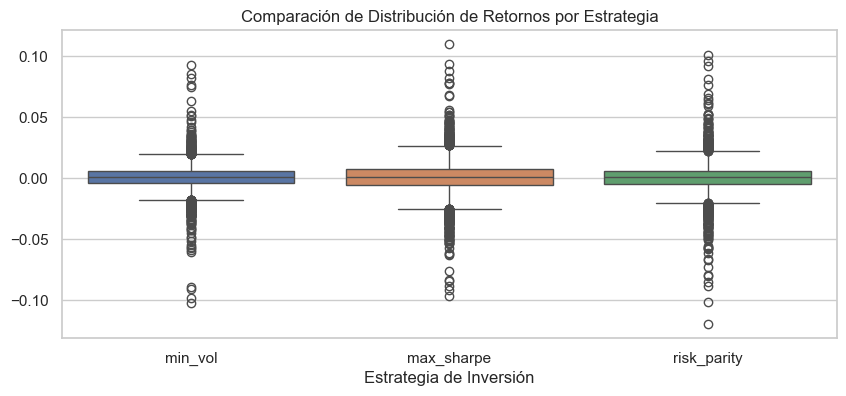

In [146]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=retornos_todas)
plt.xlabel("Estrategia de Inversión")
plt.title("Comparación de Distribución de Retornos por Estrategia")
plt.show()

## Resumen del Análisis de Rebalanceo y Variabilidad en los Pesos de los Activos

Nuestro análisis previo se centró en observar cómo el retorno de las carteras cambia a lo largo del tiempo, sin abordar las transacciones de rebalanceo necesarias para mantener las estrategias de asignación de activos. Estas transacciones son cruciales, ya que influyen significativamente en los costos operativos y el rendimiento total de la cartera.

Este análisis nos ayudará a entender la volatilidad en la asignación de los activos y evaluar cómo los ajustes frecuentes pueden afectar la estabilidad y eficiencia de nuestras estrategias de inversión.

In [147]:
pesos_min_vol_df


Ticker,PNW,PFE,CMCSA,WEC,SWKS,QCOM,BIO,AVB,MSI,KMB,HD,ATO,INCY,SPG,AXP,PHM,ROP,HON,ODFL,KO
1999-12-29,0.165,0.020,0.009,0.155,0.008,0.000,0.061,0.216,0.008,0.041,0.000,0.101,0.001,0.133,0.000,0.0,0.029,0.005,0.013,0.035
2000-03-29,0.139,0.020,0.002,0.150,0.010,0.000,0.074,0.243,0.014,0.022,0.000,0.097,0.003,0.149,0.000,0.0,0.024,0.005,0.014,0.036
2000-06-28,0.125,0.020,0.002,0.138,0.010,0.000,0.076,0.269,0.012,0.020,0.000,0.093,0.001,0.151,0.000,0.0,0.028,0.000,0.014,0.041
2000-09-27,0.118,0.026,0.008,0.134,0.012,0.000,0.095,0.292,0.011,0.021,0.000,0.079,0.000,0.123,0.000,0.0,0.021,0.007,0.015,0.037
2000-12-27,0.124,0.026,0.010,0.117,0.009,0.000,0.094,0.303,0.010,0.023,0.000,0.078,0.000,0.125,0.000,0.0,0.023,0.005,0.015,0.038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-14,0.002,0.125,0.061,0.005,0.000,0.003,0.032,0.000,0.018,0.298,0.000,0.017,0.127,0.000,0.000,0.0,0.043,0.006,0.025,0.237
2025-01-15,0.005,0.121,0.053,0.005,0.000,0.003,0.034,0.000,0.025,0.313,0.000,0.005,0.121,0.000,0.000,0.0,0.044,0.006,0.022,0.241
2025-04-16,0.014,0.093,0.039,0.072,0.000,0.011,0.014,0.000,0.041,0.243,0.044,0.037,0.090,0.000,0.000,0.0,0.089,0.000,0.000,0.212
2025-07-18,0.016,0.084,0.035,0.041,0.000,0.014,0.007,0.000,0.060,0.211,0.051,0.077,0.084,0.000,0.003,0.0,0.052,0.018,0.000,0.245


Calculo los pesos de cada activo al final de cada período y, posteriormente, determino la diferencia entre estos pesos y los asignados en el rebalanceo del período siguiente. Este análisis nos ayuda a entender cómo cambian las asignaciones de los activos entre los períodos de rebalanceo.

In [153]:
# Cáculo de variación de los pesos en cada rebalanceo.
variacion_pesos_min_vol = pesos_min_vol_df.diff().dropna()
variacion_pesos_max_sharpe = pesos_max_sharpe_df.diff().dropna()
variacion_pesos_risk_parity = pesos_risk_parity_df.diff().dropna()

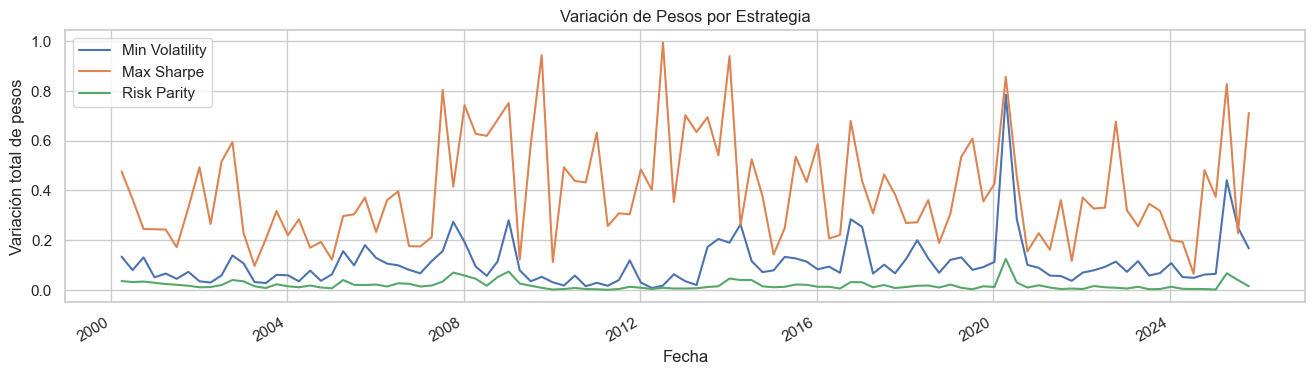

In [197]:
# Configurar el tamaño de la figura
plt.figure(figsize=(16, 4))  # Tamaño en pulgadas (ancho, alto)

# Generar las gráficas
variacion_pesos_min_vol.abs().sum(axis=1).plot(label="Min Volatility")
variacion_pesos_max_sharpe.abs().sum(axis=1).plot(label="Max Sharpe")
variacion_pesos_risk_parity.abs().sum(axis=1).plot(label="Risk Parity")

# Añadir título y etiquetas
plt.title("Variación de Pesos por Estrategia")
plt.xlabel("Fecha")  # Asumiendo que el índice es de tipo fecha
plt.ylabel("Variación total de pesos")  # Etiqueta para el eje y

# Añadir leyenda
plt.legend()

# Mostrar la gráfica
plt.show()


In [203]:
import matplotlib.animation as animation
from IPython.display import HTML

# DataFrame de pesos de la cartera
df_pesos = pesos_risk_parity_df.copy()
# df_pesos = pesos_min_vol_df.copy()
# df_pesos = pesos_max_sharpe_df.copy()


fig, ax = plt.subplots(figsize=(16, 4))

bar_container = ax.bar(df_pesos.columns, df_pesos.iloc[0], color=plt.cm.tab20.colors)
ax.set_ylim(0, 1)
ax.set_ylabel("Peso")
ax.set_xlabel("Activo")
ax.set_title("Evolución de los pesos de la cartera")


# Función de actualización para la animación
def animate(i):
    for bar, h in zip(bar_container, df_pesos.iloc[i]):
        bar.set_height(h)
    ax.set_title(f"Evolución de los pesos - Fecha: {df_pesos.index[i].strftime('%Y-%m-%d')}")
    return bar_container


ani = animation.FuncAnimation(fig, animate, frames=len(df_pesos), interval=200, blit=False, repeat=False)
plt.close(fig)
HTML(ani.to_jshtml())


Calculo el dinero rebalanceado multiplicando las diferencias entre los pesos por el precio de cada activo

In [165]:
precios_activos_rebalanceo = precios_activos_select.loc[variacion_pesos_min_vol.index]

dinero_rebalan_min_vol = (variacion_pesos_min_vol * precios_activos_rebalanceo).abs().sum(axis=1)
dinero_rebalan_max_sharpe = (variacion_pesos_max_sharpe * precios_activos_rebalanceo).abs().sum(axis=1)
dinero_rebalan_risk_parity = (variacion_pesos_risk_parity * precios_activos_rebalanceo).abs().sum(axis=1)

Calculo las comisiones pagadas

In [188]:
tasa_comision = 0.01

comisiones_min_vol = dinero_rebalan_min_vol * tasa_comision
comisiones_max_sharpe = dinero_rebalan_max_sharpe * tasa_comision
comisiones_risk_parity = dinero_rebalan_risk_parity * tasa_comision


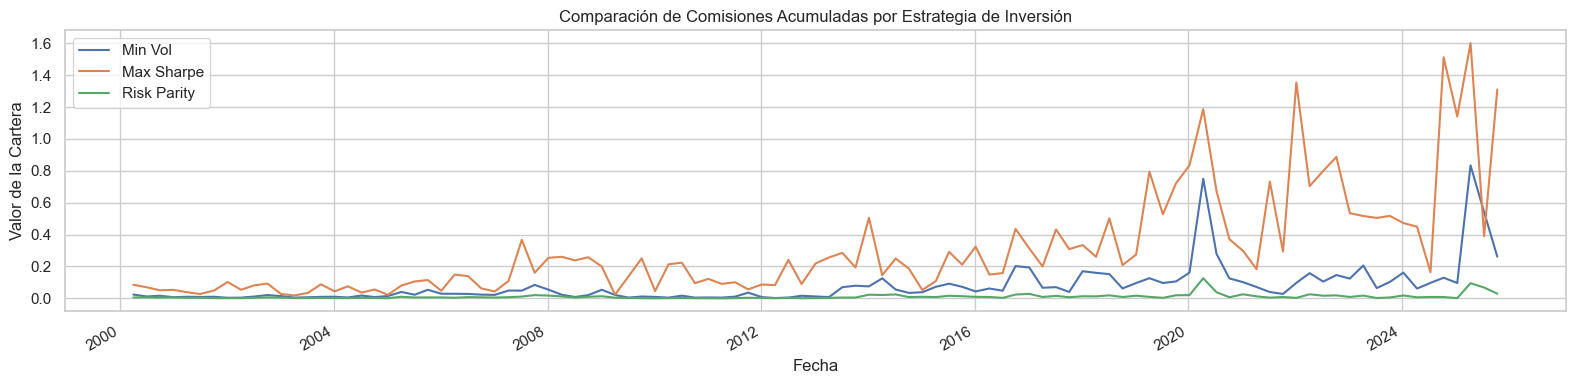

In [195]:
# Crear una figura y un eje
fig, ax = plt.subplots(figsize=(16, 4))

# Dibujar cada serie en el mismo gráfico
comisiones_min_vol.plot(ax=ax, label="Min Vol")
comisiones_max_sharpe.plot(ax=ax, label="Max Sharpe")
comisiones_risk_parity.plot(ax=ax, label="Risk Parity")

# Añadir título y etiquetas
ax.set_title("Comparación de Comisiones Acumuladas por Estrategia de Inversión")
ax.set_xlabel("Fecha")
ax.set_ylabel("Valor de la Cartera")

# Añadir leyenda
ax.legend()

# Mejorar el layout para no solapar los gráficos
plt.tight_layout()

# Mostrar la gráfica
plt.show()


In [190]:
comisiones_min_vol_df = comisiones_min_vol.reindex(index=retornos_min_vol.index, fill_value=0.0)
comisiones_max_sharpe_df = comisiones_max_sharpe.reindex(index=retornos_max_sharpe.index, fill_value=0.0)
comisiones_risk_parity_df = comisiones_risk_parity.reindex(index=retornos_risk_parity.index, fill_value=0.0)

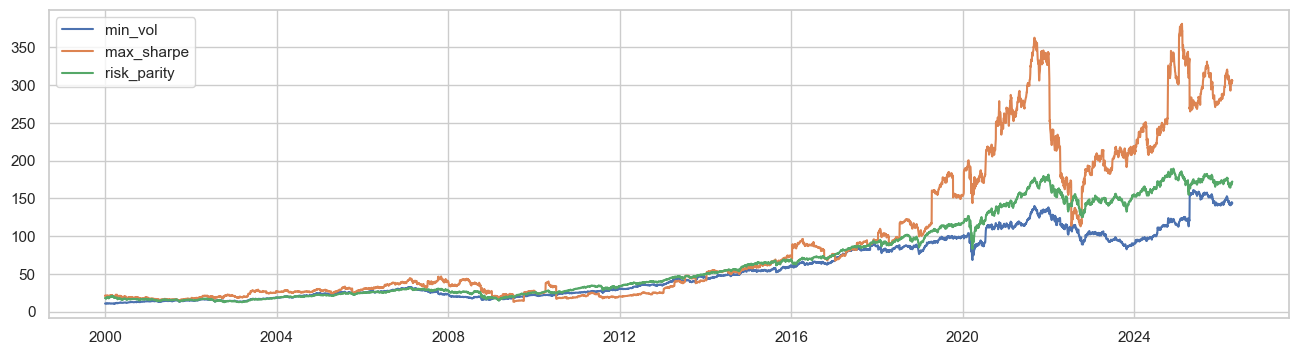

In [196]:
plt.figure(figsize=(16, 4))
plt.plot(
    pd.DataFrame(
        (precios_activos_select.loc[pesos_min_vol_daily_df.index, :] * pesos_min_vol_daily_df).sum(axis=1)
        - comisiones_min_vol_df,
        index=precios_activos_select.loc[pesos_min_vol_daily_df.index, :].index,
        columns=["min_vol"],
    ),
    label="min_vol",
)
plt.plot(
    pd.DataFrame(
        (precios_activos_select.loc[pesos_max_sharpe_daily_df.index, :] * pesos_max_sharpe_daily_df).sum(axis=1)
        - comisiones_max_sharpe_df,
        index=precios_activos_select.loc[pesos_max_sharpe_daily_df.index, :].index,
        columns=["max_sharpe"],
    ),
    label="max_sharpe",
)
plt.plot(
    pd.DataFrame(
        (precios_activos_select.loc[pesos_risk_parity_daily_df.index, :] * pesos_risk_parity_daily_df).sum(axis=1)
        - comisiones_risk_parity_df,
        index=precios_activos_select.loc[pesos_risk_parity_daily_df.index, :].index,
        columns=["risk_parity"],
    ),
    label="risk_parity",
)
plt.legend()
plt.show()
